In [2]:
import os
import pandas as pd

BASE_DIR = "final_station_data_clean"

def month_to_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Pre-monsoon"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    elif month in [10, 11]:
        return "Post-monsoon"

for station in os.listdir(BASE_DIR):
    station_path = os.path.join(BASE_DIR, station)

    if not os.path.isdir(station_path):
        continue

    for fname in os.listdir(station_path):
        if not fname.endswith(".csv"):
            continue

        file_path = os.path.join(station_path, fname)
        df = pd.read_csv(file_path)

        # parse datetime
        df["timestamp"] = pd.to_datetime(df["timestamp"])

        # add season logic
        df["month"] = df["timestamp"].dt.month
        df["season"] = df["month"].apply(month_to_season)

        # overwrite original file
        df.to_csv(file_path, index=False)

print("✅ All files overwritten with 'month' and 'season' columns.")


✅ All files overwritten with 'month' and 'season' columns.


In [3]:
import os
import pandas as pd

BASE_DIR = "final_station_data_clean"
PM_COL = "PM 2.5"   # UPDATED column name

records = []

for station in os.listdir(BASE_DIR):
    station_path = os.path.join(BASE_DIR, station)

    if not os.path.isdir(station_path):
        continue

    for fname in os.listdir(station_path):
        if not fname.endswith(".csv"):
            continue

        file_path = os.path.join(station_path, fname)
        df = pd.read_csv(file_path)

        # group by season
        grouped = df.groupby("season")[PM_COL]

        stats = grouped.agg(
            mean_pm25="mean",
            median_pm25="median",
            std_pm25="std"
        ).reset_index()

        stats["station"] = station
        stats["year"] = fname.replace(".csv", "")

        records.append(stats)

# combine all station-year results
stationwise_df = pd.concat(records, ignore_index=True)

# save
stationwise_df.to_csv(
    "seasonal_pm25_stats_stationwise.csv",
    index=False
)

print("✅ Station-wise seasonal statistics saved.")


✅ Station-wise seasonal statistics saved.


In [4]:
import pandas as pd

# load station-wise stats
df = pd.read_csv("seasonal_pm25_stats_stationwise.csv")

# average across years per station
station_season_avg = (
    df.groupby(["station", "season"])["mean_pm25"]
      .mean()
      .reset_index()
)

# network-level average (equal weight per station)
network_season_avg = (
    station_season_avg.groupby("season")["mean_pm25"]
        .mean()
        .reset_index(name="network_mean_pm25")
)

# save
network_season_avg.to_csv(
    "seasonal_pm25_stats_network.csv",
    index=False
)

print("✅ Network-level seasonal PM2.5 saved.")


✅ Network-level seasonal PM2.5 saved.


In [5]:
import os
import pandas as pd

BASE_DIR = "final_station_data_clean"
PM_COL = "PM 2.5"

records = []

for station in os.listdir(BASE_DIR):
    station_path = os.path.join(BASE_DIR, station)

    if not os.path.isdir(station_path):
        continue

    for fname in os.listdir(station_path):
        if not fname.endswith(".csv"):
            continue

        file_path = os.path.join(station_path, fname)
        df = pd.read_csv(file_path)

        # compute seasonal statistics for this station-year
        stats = (
            df.groupby("season")[PM_COL]
              .agg(mean_pm25="mean",
                   median_pm25="median",
                   std_pm25="std")
              .reset_index()
        )

        stats["station"] = station
        stats["year"] = fname.replace(".csv", "")

        records.append(stats)

# combine all station-year stats
stationwise_df = pd.concat(records, ignore_index=True)

stationwise_df.to_csv(
    "seasonal_pm25_stats_stationwise.csv",
    index=False
)

print("✅ Task A2-1 complete: station-wise seasonal PM₂.₅ statistics saved.")


✅ Task A2-1 complete: station-wise seasonal PM₂.₅ statistics saved.


In [6]:
import pandas as pd

df = pd.read_csv("seasonal_pm25_stats_stationwise.csv")

# average across years per station
station_season_avg = (
    df.groupby(["station", "season"])["mean_pm25"]
      .mean()
      .reset_index()
)

# network-level seasonal mean (equal weight per station)
network_season_avg = (
    station_season_avg.groupby("season")["mean_pm25"]
        .mean()
        .reset_index(name="network_mean_pm25")
)

network_season_avg.to_csv(
    "seasonal_pm25_stats_network.csv",
    index=False
)

print("✅ Task A2-2 complete: network-level seasonal PM₂.₅ saved.")


✅ Task A2-2 complete: network-level seasonal PM₂.₅ saved.


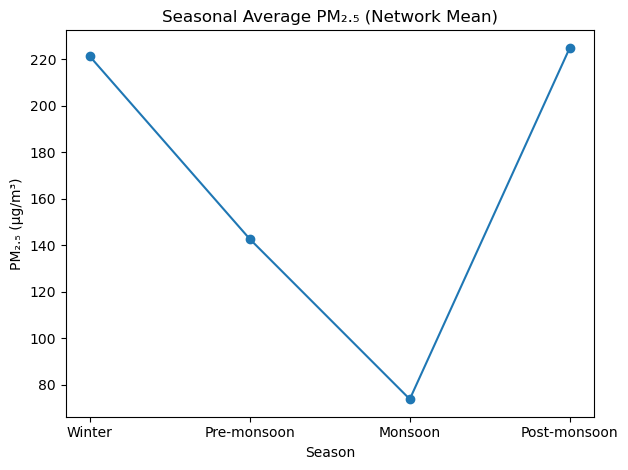

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("seasonal_pm25_stats_network.csv")

season_order = ["Winter", "Pre-monsoon", "Monsoon", "Post-monsoon"]
df["season"] = pd.Categorical(df["season"], season_order)
df = df.sort_values("season")

plt.figure()
plt.plot(df["season"], df["network_mean_pm25"], marker="o")
plt.xlabel("Season")
plt.ylabel("PM₂.₅ (µg/m³)")
plt.title("Seasonal Average PM₂.₅ (Network Mean)")
plt.tight_layout()
plt.show()


In [8]:
import os
import pandas as pd

BASE_DIR = "final_station_data_clean"
PM_COL = "PM 2.5"

records = []

for station in os.listdir(BASE_DIR):
    station_path = os.path.join(BASE_DIR, station)

    if not os.path.isdir(station_path):
        continue

    for fname in os.listdir(station_path):
        if not fname.endswith(".csv"):
            continue

        file_path = os.path.join(station_path, fname)
        df = pd.read_csv(file_path)

        # monthly mean for this station-year
        stats = (
            df.groupby("month")[PM_COL]
              .mean()
              .reset_index(name="mean_pm25")
        )

        stats["station"] = station
        stats["year"] = fname.replace(".csv", "")

        records.append(stats)

station_month_df = pd.concat(records, ignore_index=True)

station_month_df.to_csv(
    "monthly_pm25_stationwise.csv",
    index=False
)

print("✅ Station-wise monthly PM₂.₅ saved.")


✅ Station-wise monthly PM₂.₅ saved.


In [9]:
import pandas as pd

df = pd.read_csv("monthly_pm25_stationwise.csv")

# average across years per station
station_month_avg = (
    df.groupby(["station", "month"])["mean_pm25"]
      .mean()
      .reset_index()
)

# network-level monthly mean
network_month_avg = (
    station_month_avg.groupby("month")["mean_pm25"]
        .mean()
        .reset_index(name="network_mean_pm25")
)

network_month_avg.to_csv(
    "monthly_pm25_network.csv",
    index=False
)

print("✅ Network-level monthly PM₂.₅ saved.")


✅ Network-level monthly PM₂.₅ saved.


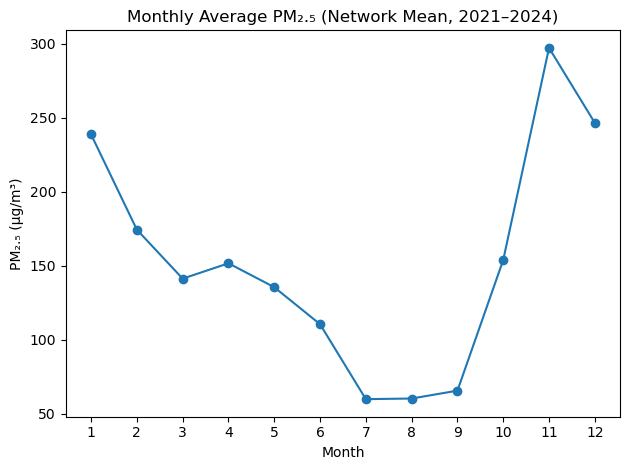

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("monthly_pm25_network.csv")

# month order
df = df.sort_values("month")

plt.figure()
plt.plot(df["month"], df["network_mean_pm25"], marker="o")
plt.xlabel("Month")
plt.ylabel("PM₂.₅ (µg/m³)")
plt.title("Monthly Average PM₂.₅ (Network Mean, 2021–2024)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()
